In [ ]:
!pip install awscli
!pip install gdown
!pip install parquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.8 MB/s eta 0:00:00


In [ ]:
## downloading raw files
!aws s3 sync \
  --no-sign-request \
  s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data .

download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pclfc.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pclfc.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pczscore.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pczscore.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k_vczscore.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k_vczscore.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/treatment_level_l1k.csv.gz to CDRP-BBBC047-Bray/L1000/treatment_level_l1k.csv.

In [ ]:
## downloading curated files
!gdown 1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD -O data.zip
!unzip data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD
From (redirected): https://drive.google.com/uc?id=1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD&confirm=t&uuid=630e3247-a394-40a2-87ce-d3610538c9bb
To: /content/data.zip
100% 2.73G/2.73G [01:34<00:00, 28.8MB/s]
Archive:  data.zip
   creating: curated/
  inflating: curated/.DS_Store       
  inflating: __MACOSX/curated/._.DS_Store  
   creating: curated/LINCS-Pilot1/
   creating: curated/CDRP-BBBC047-Bray/
   creating: curated/TA-ORF-BBBC037-Rohban/
   creating: curated/LUAD-BBBC041-Caicedo/
   creating: curated/LINCS-Pilot1/CellPainting/
  inflating: curated/LINCS-Pilot1/.DS_Store  
  inflating: __MACOSX/curated/LINCS-Pilot1/._.DS_Store  
   creating: curated/LINCS-Pilot1/L1000/
   creating: curated/CDRP-BBBC047-Bray/CellPainting/
  inflating: curated/CDRP-BBBC047-Bray/.DS_Store  
  inflating: __MACOSX/curated/CDRP-BBBC047-Bray/._.DS_Store  
   creating: curated/CDRP-BBBC047-Bray/L1000/
   creating: cu

In [ ]:
## unzipping
!gunzip /content/LINCS-Pilot1/L1000/replicate_level_l1k.csv.gz
!gunzip /content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv.gz

## Reading CellProfiler and L1000 datasets

In [ ]:
import pyarrow.parquet as pa
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [ ]:
l1000_curated = pa.read_table("/content/curated/LINCS-Pilot1/L1000/replicate_level_l1k.parquet").to_pandas()
cellpainting_curated = pa.read_table("/content/curated/LINCS-Pilot1/CellPainting/replicate_level_cp_augmented.parquet").to_pandas()

In [ ]:
l1000_raw = pd.read_csv("/content/LINCS-Pilot1/L1000/replicate_level_l1k.csv")
cellpainting_raw = pd.read_csv("/content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv")

/tmp/ipython-input-1297697425.py:2: DtypeWarning: Columns (18,19,1820,1821) have mixed types. Specify dtype option on import or set low_memory=False.
  cellpainting_raw = pd.read_csv("/content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv")


In [ ]:
l1000_curated["moa"] = l1000_raw["moa"].fillna("Unknown/Missing")
l1000_curated["pert_id_dose"] = l1000_raw["pert_id_dose"]

cellpainting_curated["moa"] = cellpainting_raw["moa"].fillna("Unknown/Missing")
cellpainting_curated["pert_id_dose"] = cellpainting_raw["Metadata_pert_id_dose"]
cellpainting_curated['pert_id_dose'] = cellpainting_curated['pert_id_dose'].astype(str).str.replace(r'\.0$', '', regex=True)

## Data preprocessing

In [ ]:
## intersections of permutation dose
pert_dose = set(l1000_curated["pert_id_dose"]) & set(cellpainting_curated["pert_id_dose"])
cellpainting_curated = cellpainting_curated[cellpainting_curated["pert_id_dose"].isin(pert_dose)]
l1000_curated = l1000_curated[l1000_curated["pert_id_dose"].isin(pert_dose)]

In [ ]:
class ZCASpherizer:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.mean_ = None
        self.W_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        sigma = np.dot(X_centered.T, X_centered) / (X.shape[0] - 1)
        U, S, _ = np.linalg.svd(sigma)
        inv_sqrt_S = np.diag(1.0 / np.sqrt(S + self.epsilon))
        self.W_ = np.dot(np.dot(U, inv_sqrt_S), U.T)
        return self

    def transform(self, X):
        return np.dot(X - self.mean_, self.W_.T)

In [ ]:
def preprocess_cp(df, meta_cols):
    numeric_df = df.drop(columns=meta_cols, errors='ignore').select_dtypes(include=['number'])
    meta_df = df[meta_cols]

    sel = VarianceThreshold(threshold=0.01)
    data_var = sel.fit_transform(numeric_df)
    current_cols = numeric_df.columns[sel.get_support()]
    data_df = pd.DataFrame(data_var, index=df.index, columns=current_cols)

    corr_matrix = data_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
    data_corr = data_df.drop(columns=to_drop)

    valid_cols = (data_corr >= 0).all()
    data_corr = data_corr.loc[:, valid_cols]
    data_log = np.log1p(data_corr)

    controls = meta_df['pert_id_dose'].isin(['negcon'])

    if not controls.any():
        print("test")
        controls = pd.Series([True] * len(df), index=df.index)

    scaler = RobustScaler().fit(data_log.loc[controls])
    data_scaled = scaler.transform(data_log)

    spherizer = ZCASpherizer().fit(data_scaled[controls])
    data_final = spherizer.transform(data_scaled)

    data_final_df = pd.DataFrame(data_final, columns=data_corr.columns, index=df.index)

    return pd.concat([meta_df, data_final_df], axis=1)

cp_clean = preprocess_cp(cellpainting_curated, ['pert_id_dose', 'moa'])
cp_clean.loc[cp_clean['pert_id_dose'] == 'negcon', 'moa'] = 'Control vehicle'

In [ ]:
def preprocess_l1000(df, meta_cols):
    numeric_df = df.drop(columns=meta_cols, errors='ignore').select_dtypes(include=['number'])
    meta_df = df[meta_cols].reset_index(drop=True)
    return pd.concat([meta_df, numeric_df], axis=1)

l1000_clean = preprocess_l1000(l1000_curated, ['pert_id_dose', 'moa', 'Metadata_pert_iname'])

In [ ]:
cp_metadata_cols = ["pert_id_dose", "moa"]
cp_feature_cols = [c for c in cp_clean.columns if c not in cp_metadata_cols]
cp_collapsed = (cp_clean.groupby(["pert_id_dose", "moa"], as_index=False)[cp_feature_cols].median())

In [ ]:
l1000_metadata_cols = ["pert_id_dose", "moa", "Metadata_pert_iname"]
l1000_feature_cols = [c for c in l1000_clean.columns if c not in l1000_metadata_cols]
l1000_collapsed = (l1000_clean.groupby(["pert_id_dose", "moa", 'Metadata_pert_iname'], as_index=False)[l1000_feature_cols].median())

In [ ]:
# merging non-controls
cp_mask = (cp_clean['pert_id_dose'] == 'negcon') & (cp_clean['moa'] == 'Control vehicle')
l1_mask = (l1000_clean['pert_id_dose'] == 'negcon') & (l1000_clean['moa'] == 'Control vehicle')


merged_treatments = pd.merge(
    cp_clean[~cp_mask],
    l1000_clean[~l1_mask],
    on=['pert_id_dose', 'moa'],
    how='inner',
    suffixes=('_cp', '_l1000')
)

n_samples = 10000
cp_ctl = cp_clean[cp_mask].sample(n=n_samples, replace=True).reset_index(drop=True)
l1_ctl = l1000_clean[l1_mask].sample(n=n_samples, replace=True).reset_index(drop=True)

cp_ctl['join_key'] = range(n_samples)
l1_ctl['join_key'] = range(n_samples)

merged_controls = pd.merge(
    cp_ctl,
    l1_ctl,
    on=['join_key', 'pert_id_dose', 'moa'],
    suffixes=('_cp', '_l1000')
).drop(columns='join_key')

# combine controls and non-controls
original_lincs_df = pd.concat([merged_treatments, merged_controls], axis=0, ignore_index=True)

## processing pipes in moa
original_lincs_df['moa'] = original_lincs_df['moa'].str.split('|')
original_lincs_df = original_lincs_df.explode('moa').reset_index(drop=True)
original_lincs_df.insert(0, 'Metadata_pert_iname', original_lincs_df.pop('Metadata_pert_iname'))

In [ ]:
# merging non-controls

lincs_df = pd.merge(
    cp_collapsed,
    l1000_collapsed,
    on=['pert_id_dose', 'moa'],
    how='inner',
    suffixes=('_cp', '_l1000')
)

## processing pipes in moa
lincs_df['moa'] = lincs_df['moa'].str.split('|')
lincs_df = lincs_df.explode('moa').reset_index(drop=True)
lincs_df.insert(0, 'Metadata_pert_iname', lincs_df.pop('Metadata_pert_iname'))

## Data prep for ML

In [ ]:
def prepare_data(df):
    unique_treatments = df[df['Metadata_pert_iname'] != 'DMSO']['Metadata_pert_iname'].unique()
    train_treats, test_treats = train_test_split(unique_treatments, test_size=0.2, random_state=42)

    train_mask = df['Metadata_pert_iname'].isin(train_treats)
    test_mask = df['Metadata_pert_iname'].isin(test_treats)

    train_df = df[train_mask].reset_index(drop=True)
    test_df = df[test_mask].reset_index(drop=True)

    le = LabelEncoder()
    le.fit(unique_treatments)

    return train_df, test_df, le

train_df, test_df, label_encoder = prepare_data(final_df)

In [ ]:
train_df

,Metadata_pert_iname,pert_id_dose,moa,Metadata_pert_dose_micromolar_cp,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,...,155,156,157,158,159,160,161,162,163,164
0,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,0.043574,0.437766,-0.169460,0.526737,-1.620727,0.083957,-2.277817,-1.260357,2.302227,14.071527
1,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,-0.218794,0.117265,0.045191,0.424049,-0.575114,0.142507,-0.686728,-0.425452,1.332408,8.833854
2,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,-0.554615,-0.023002,0.049775,0.282146,1.379483,1.219656,0.798212,-1.188702,4.514425,23.571701
3,methoxsalen,BRD-K63430059_3.33,DNA synthesis inhibitor,1466.326807,-0.728949,0.231320,0.145304,-0.642461,0.407158,1.079414,...,-0.107006,0.176388,-0.047469,0.500569,-1.398496,0.474135,-2.101211,-1.347276,2.930733,15.571288
4,methoxsalen,BRD-K63430059_3.33,DNA synthesis inhibitor,1466.326807,-0.728949,0.231320,0.145304,-0.642461,0.407158,1.079414,...,-0.048088,0.137074,-0.451030,0.164215,-1.535575,1.174118,-1.868928,-1.726628,6.506698,32.544525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18336,tozasertib,BRD-K59369769_0.04,JAK inhibitor,40.327722,-1.716304,0.508231,0.760346,0.060032,-1.586619,0.671660,...,-0.087284,0.197804,-0.095308,0.278746,-1.257230,-0.008114,-1.310735,-0.383067,1.827775,11.671096
18337,tozasertib,BRD-K59369769_0.04,Aurora kinase inhibitor,40.327722,-1.716304,0.508231,0.760346,0.060032,-1.586619,0.671660,...,-0.056137,0.098431,-0.178957,0.329580,-1.204723,0.088373,-1.285446,-0.445621,1.771440,10.653090
18338,tozasertib,BRD-K59369769_0.04,Bcr-Abl kinase inhibitor,40.327722,-1.716304,0.508231,0.760346,0.060032,-1.586619,0.671660,...,-0.056137,0.098431,-0.178957,0.329580,-1.204723,0.088373,-1.285446,-0.445621,1.771440,10.653090
18339,tozasertib,BRD-K59369769_0.04,FLT3 inhibitor,40.327722,-1.716304,0.508231,0.760346,0.060032,-1.586619,0.671660,...,-0.056137,0.098431,-0.178957,0.329580,-1.204723,0.088373,-1.285446,-0.445621,1.771440,10.653090


In [ ]:
test_df.shape

(292, 1146)

In [ ]:
class LincsDataset(Dataset):
    def __init__(self, df, label_encoder):
        self.cp_data = df.iloc[:, 3:168].values.astype(np.float32)
        self.l1000_data = df.iloc[:, 168:].values.astype(np.float32)
        self.labels = label_encoder.transform(df['Metadata_pert_iname'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.cp_data[idx]),
                torch.tensor(self.l1000_data[idx]),
                torch.tensor(self.labels[idx]))

## Learning

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class GeneToMorphology(nn.Module):
    def __init__(self, gene_dim, cp_dim, dropout_rate=0.5):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(gene_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, cp_dim)
        )

    def forward(self, x_gene):
        return self.net(x_gene)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cp_dim = 165
gene_dim = final_df.shape[1] - 168
patience = 5
min_delta = 0.001
best_loss = float('inf')
counter = 0

train_history = []
val_history = []

train_dataset = LincsDataset(train_df, label_encoder)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = LincsDataset(test_df, label_encoder)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = GeneToMorphology(gene_dim, cp_dim, dropout_rate=0.5).to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

epochs = 10000

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_embeddings = []
    train_labels = []

    for batch_cp, batch_gene, batch_labels in train_loader:
        batch_cp, batch_gene = batch_cp.to(device), batch_gene.to(device)

        preds = model(batch_gene)
        loss = criterion(preds, batch_cp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_embeddings.append(preds.detach().cpu().numpy())
        train_labels.append(batch_labels.cpu().numpy())

    train_embeddings = np.concatenate(train_embeddings, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)

    avg_train_loss = train_loss / len(train_loader)
    train_history.append(avg_train_loss)

    model.eval()
    val_loss = 0
    test_embeddings = []
    test_labels = []
    with torch.no_grad():
        for batch_cp, batch_gene, batch_labels in test_loader:
            batch_cp, batch_gene = batch_cp.to(device), batch_gene.to(device)
            preds = model(batch_gene)
            loss = criterion(preds, batch_cp)
            val_loss += loss.item()
            test_embeddings.append(preds.detach().cpu().numpy())
            test_labels.append(batch_labels.cpu().numpy())

    test_embeddings = np.concatenate(test_embeddings, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    avg_val_loss = val_loss / len(test_loader)
    val_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < (best_loss - min_delta):
        best_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_model.pth', weights_only=True))


Epoch 1: Train Loss: 8559.4311 | Val Loss: 8550.2382
Epoch 2: Train Loss: 8520.0630 | Val Loss: 8510.8880
Epoch 3: Train Loss: 8481.8523 | Val Loss: 8483.6188
Epoch 4: Train Loss: 8445.0889 | Val Loss: 8439.7850
Epoch 5: Train Loss: 8389.8313 | Val Loss: 8398.4717
Epoch 6: Train Loss: 8329.5798 | Val Loss: 8326.4683
Epoch 7: Train Loss: 8271.9033 | Val Loss: 8275.1012
Epoch 8: Train Loss: 8197.8513 | Val Loss: 8204.1191
Epoch 9: Train Loss: 8124.8610 | Val Loss: 8124.3231
Epoch 10: Train Loss: 8045.7999 | Val Loss: 8051.8925
Epoch 11: Train Loss: 7963.9121 | Val Loss: 8003.5420
Epoch 12: Train Loss: 7878.0254 | Val Loss: 7918.8500
Epoch 13: Train Loss: 7793.1304 | Val Loss: 7843.6375
Epoch 14: Train Loss: 7706.0910 | Val Loss: 7802.6063
Epoch 15: Train Loss: 7607.5940 | Val Loss: 7719.9908
Epoch 16: Train Loss: 7515.9956 | Val Loss: 7640.4531
Epoch 17: Train Loss: 7414.6038 | Val Loss: 7566.3807
Epoch 18: Train Loss: 7307.0076 | Val Loss: 7402.0730
Epoch 19: Train Loss: 7215.0676 | Val

<All keys matched successfully>

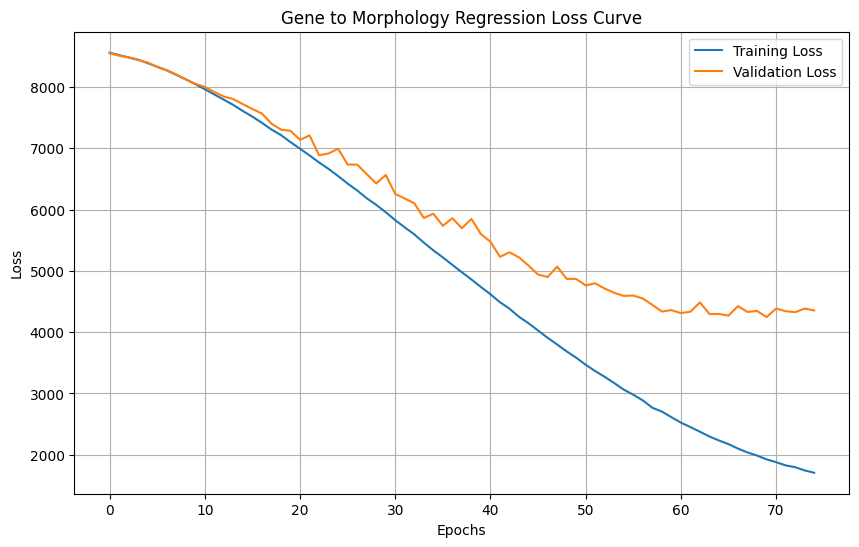

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_history, label='Training Loss')
plt.plot(val_history, label='Validation Loss')
plt.title('Gene to Morphology Regression Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
pert_moa = dict(zip(lincs_df['Metadata_pert_iname'], lincs_df['moa']))

In [ ]:
moa_list = train_df['moa'].unique()
moa_list.sort()
moa_to_idx = {moa: idx for idx, moa in enumerate(moa_list)}

In [ ]:
moa_to_idx = {'3-ketoacyl CoA thiolase inhibitor': 0,
 '3beta-hydroxy-delta5-steroid dehydrogenase inhibitor': 1,
 '5 alpha reductase inhibitor': 2,
 'ACAT inhibitor': 3,
 'AKT inhibitor': 4,
 'ALK tyrosine kinase receptor inhibitor': 5,
 'AMPK activator': 6,
 'ATP channel blocker': 7,
 'ATPase inhibitor': 8,
 'Aurora kinase inhibitor': 9,
 'BCL inhibitor': 10,
 'Bcr-Abl kinase inhibitor': 11,
 'CC chemokine receptor antagonist': 12,
 'CCK receptor antagonist': 13,
 'CD antagonist': 14,
 'CDK inhibitor': 15,
 'CFTR channel antagonist': 16,
 'CMV terminase inhibitor': 17,
 'CRTH receptor antagonist': 18,
 'DNA alkylating agent': 19,
 'DNA directed DNA polymerase inhibitor': 20,
 'DNA inhibitor': 21,
 'DNA methyltransferase inhibitor': 22,
 'DNA polymerase inhibitor': 23,
 'DNA synthesis inhibitor': 24,
 'EGFR inhibitor': 25,
 'FGFR inhibitor': 26,
 'FLT3 inhibitor': 27,
 'GABA receptor antagonist': 28,
 'GABA receptor modulator': 29,
 'GABA uptake inhibitor': 30,
 'GAT inhibitor': 31,
 'GK0582 inhibitor': 32,
 'HCN channel blocker': 33,
 'HCV inhibitor': 34,
 'HDAC inhibitor': 35,
 'HIV integrase inhibitor': 36,
 'HIV protease inhibitor': 37,
 'HMGCR inhibitor': 38,
 'HSP inhibitor': 39,
 'IKK inhibitor': 40,
 'JAK inhibitor': 41,
 'KIT inhibitor': 42,
 'LDL receptor activator': 43,
 'MDM inhibitor': 44,
 'MEK inhibitor': 45,
 'N-type calcium channel blocker': 46,
 'NADPH inhibitor': 47,
 'NFkB pathway inhibitor': 48,
 'PARP inhibitor': 49,
 'PDGFR tyrosine kinase receptor inhibitor': 50,
 'PI3K inhibitor': 51,
 'PKC activator': 52,
 'PKC inhibitor': 53,
 'PLK inhibitor': 54,
 'PPAR receptor agonist': 55,
 'PPAR receptor antagonist': 56,
 'Pim kinase inhibitor': 57,
 'RAD51 inhibitor': 58,
 'RAF inhibitor': 59,
 'RET tyrosine kinase inhibitor': 60,
 'RNA polymerase inhibitor': 61,
 'RNA synthesis inhibitor': 62,
 'SIRT inhibitor': 63,
 'STAT inhibitor': 64,
 'SYK inhibitor': 65,
 'T-type calcium channel blocker': 66,
 'TGF beta receptor inhibitor': 67,
 'TRAIL modulator': 68,
 'TRPV agonist': 69,
 'VEGFR inhibitor': 70,
 'WEE1 kinase inhibitor': 71}


In [ ]:
mapping_df = pd.DataFrame()
mapping_df['Metadata_pert_iname'] = label_encoder.classes_
mapping_df['moa'] = mapping_df['Metadata_pert_iname'].map(pert_moa)
mapping_df['index']=mapping_df.index
mapping_df['unique_moa_label'] = mapping_df['moa'].map(moa_to_idx)
mapping_df['unique_moa_label'] = mapping_df['unique_moa_label'].fillna(0).astype(int)
mapping_df

,Metadata_pert_iname,moa,index,unique_moa_label
0,3-amino-benzamide,PARP inhibitor,0,49
1,ABT-737,BCL inhibitor,1,10
2,AZ-628,RAF inhibitor,2,59
3,AZD-5438,CDK inhibitor,3,15
4,AZD-8330,MEK inhibitor,4,45
...,...,...,...,...
219,vicriviroc,CC chemokine receptor antagonist,219,12
220,volasertib,PLK inhibitor,220,54
221,xl888,HSP inhibitor,221,39
222,z160,N-type calcium channel blocker,222,46


In [ ]:
label_dict = dict(zip(mapping_df['index'], mapping_df['unique_moa_label']))

In [ ]:
train_labels_mapped = np.array([label_dict[int(x)] for x in train_labels])
test_labels_mapped = np.array([label_dict[int(x)] for x in test_labels])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.mixture import GaussianMixture

normalize = Normalizer(norm='l2')
X_train = normalize.fit_transform(train_embeddings)
y_train = train_labels_mapped
X_test = normalize.fit_transform(test_embeddings)
y_test = test_labels_mapped


Text(0.5, 1.0, 'Effect of K')

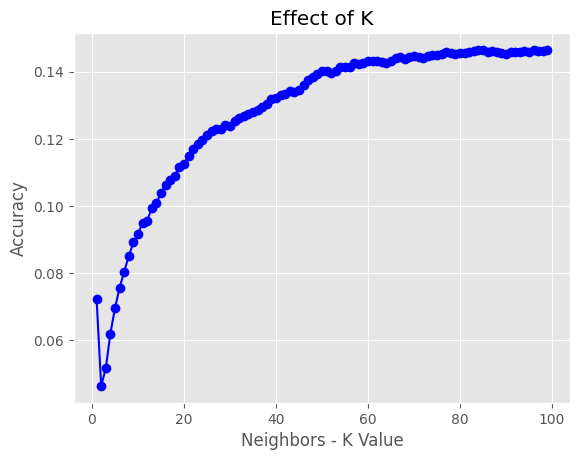

In [ ]:
k_values = list(range(1, 100))
acc_scores = []

from sklearn.model_selection import cross_val_score

for k in k_values:
  KNN = KNeighborsClassifier(n_neighbors=k)

  scores = cross_val_score(KNN, X_train, y_train,
                           scoring='accuracy', cv=5)

  acc_scores.append(np.mean(scores))

plt.style.use("ggplot")

plt.plot(k_values, acc_scores, marker='o', color='blue')
plt.xlabel("Neighbors - K Value")
plt.ylabel("Accuracy")
plt.title("Effect of K")

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from scipy.special import logsumexp

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pca_n = 10
pca = PCA(n_components=pca_n, random_state=0)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

classes = np.unique(y_train)
gmms = {}
class_counts = {c: np.sum(y_train == c) for c in classes}
for c in classes:
    Xc = X_train_p[y_train == c]
    n_comp = 1
    cov_type = 'diag'
    gmms[c] = GaussianMixture(
        n_components=n_comp,
        covariance_type=cov_type,
        reg_covar=1e-6,
        random_state=0
    ).fit(Xc)

priors = {c: class_counts[c] / len(y_train) for c in classes}
log_liks = np.column_stack([gmms[c].score_samples(X_test_p) + np.log(priors[c] + 1e-12)
                            for c in classes])
pred_idx = np.argmax(log_liks, axis=1)
y_pred = classes[pred_idx]

all_classes = np.arange(72)
f1_per_class = f1_score(y_test, y_pred, average=None, labels=all_classes)
f1_micro = f1_score(y_test,  y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test,  y_pred, average='weighted')

print("F1 score per class:", f1_per_class)
print("Micro-average F1 score:", f1_micro)
print("Macro-average F1 score:", f1_macro)
print("Weighted-average F1 score:", f1_weighted)
for c_i, c in enumerate(classes):
    print(f"Class {c}: count(train)={class_counts[c]}, F1={f1_per_class[c_i]:.3f}")


F1 score per class: [0.12345679 0.         0.         0.         0.         0.
 0.         0.         0.05319149 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.07925408
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.07434944 0.        ]
Micro-average F1 score: 0.030097993467102194
Macro-average F1 score: 0.0067398326758861295
Weighted-average F1 score: 0.020959615588982832
Class 0: count(train)=810, F1=0.123
Class 1: count(train)=90, F1=0.000
Class 2: count(train)=180, F1=0.000
Class 3: 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=100, metric = 'cosine')
knn_classifier.fit(X_train, y_train)
predicted_labels = knn_classifier.predict(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score


mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=64,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    verbose=True
)

# Train
mlp.fit(X_train, y_train)

# Predict
predicted_labels = mlp.predict(X_test)

# Metrics
all_classes = np.arange(72)
f1_per_class = f1_score(y_test, predicted_labels, average=None, labels=all_classes)
f1_micro = f1_score(y_test, predicted_labels, average='micro')
f1_macro = f1_score(y_test, predicted_labels, average='macro')
f1_weighted = f1_score(y_test, predicted_labels, average='weighted')

print("F1 score per class:", f1_per_class)
print("Micro-average F1 score:", f1_micro)
print("Macro-average F1 score:", f1_macro)
print("Weighted-average F1 score:", f1_weighted)


Iteration 1, loss = 4.04360796
Validation score: 0.149606
Iteration 2, loss = 3.80505817
Validation score: 0.149606
Iteration 3, loss = 3.72625362
Validation score: 0.149606
Iteration 4, loss = 3.70738591
Validation score: 0.149606
Iteration 5, loss = 3.69750889
Validation score: 0.149606
Iteration 6, loss = 3.68679573
Validation score: 0.149606
Iteration 7, loss = 3.68151896
Validation score: 0.149606
Iteration 8, loss = 3.67640179
Validation score: 0.149606
Iteration 9, loss = 3.66661988
Validation score: 0.149606
Iteration 10, loss = 3.65991943
Validation score: 0.141732
Iteration 11, loss = 3.65483909
Validation score: 0.141732
Iteration 12, loss = 3.64727103
Validation score: 0.141732
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
F1 score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
np.save('raw_uncollapsed_embeddings_gene_morph_gmm_f1.npy', f1_per_class)

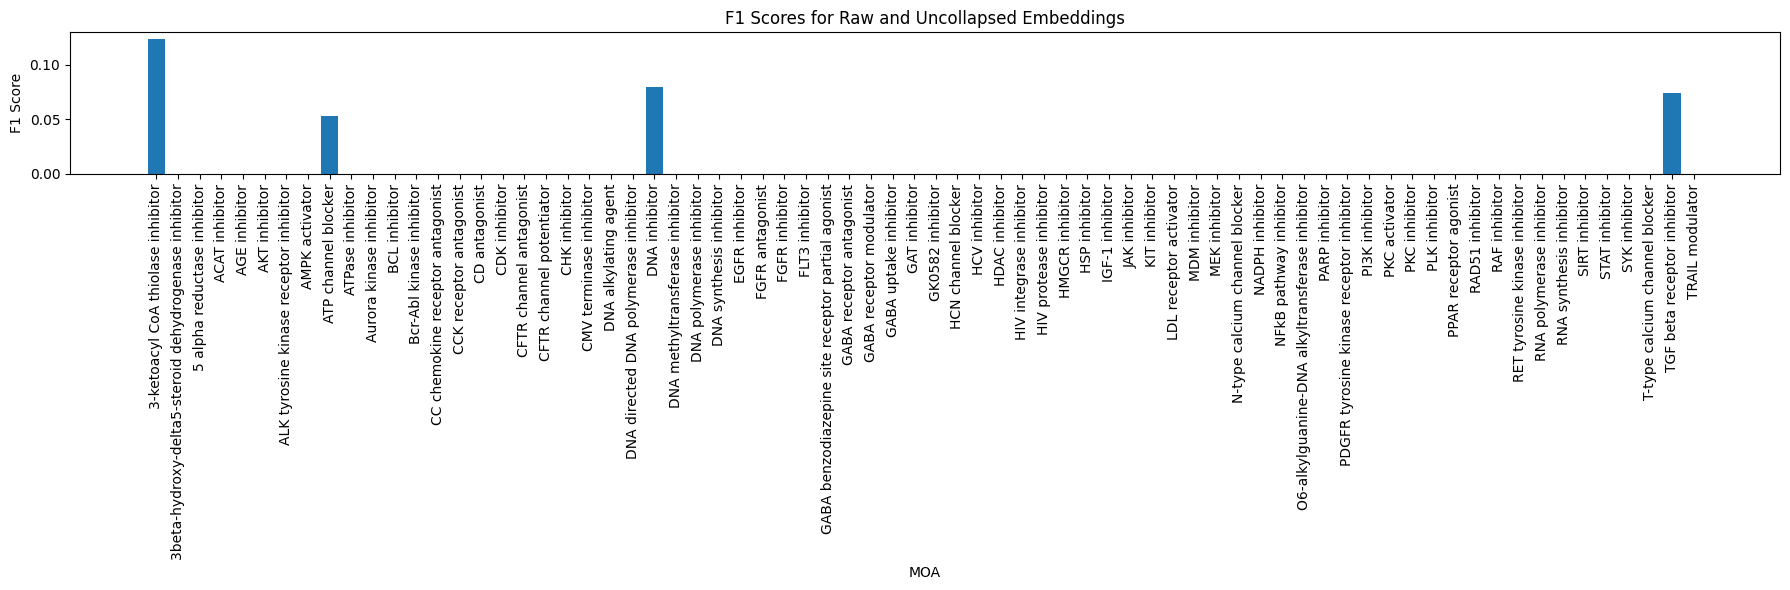

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Corrected line: Use moa_list to get names from indices
class_names = [moa_list[i] for i in all_classes]

plt.figure(figsize=(18, 6))
plt.bar(class_names, f1_per_class)
plt.xticks(rotation=90)
plt.xlabel("MOA")
plt.ylabel("F1 Score")
plt.title("F1 Scores for Raw and Uncollapsed Embeddings")
plt.tight_layout()
plt.savefig('raw_uncollapsed_gene_morph_gmm_F1.png')
plt.show()

In [ ]:
np.save('raw_uncollapsed_training_embeddings.npy', train_embeddings)
np.save('raw_uncollapsed_testing_embeddings.npy', test_embeddings)
np.save('raw_uncollapsed_training_labels.npy', train_labels_mapped)
np.save('raw_uncollapsed_testing_labels.npy', test_labels_mapped)

In [ ]:
group_1 = np.load('uncollapsed_embeddings_gene_morph_gmm_f1.npy')
group_2 = np.load('raw_uncollapsed_embeddings_gene_morph_gmm_f1.npy')
group_3 = np.load('collapsed_embeddings_gene_morph_gmm_f1.npy')
group_4 = np.load('raw_collapsed_embeddings_gene_morph_gmm_f1.npy')

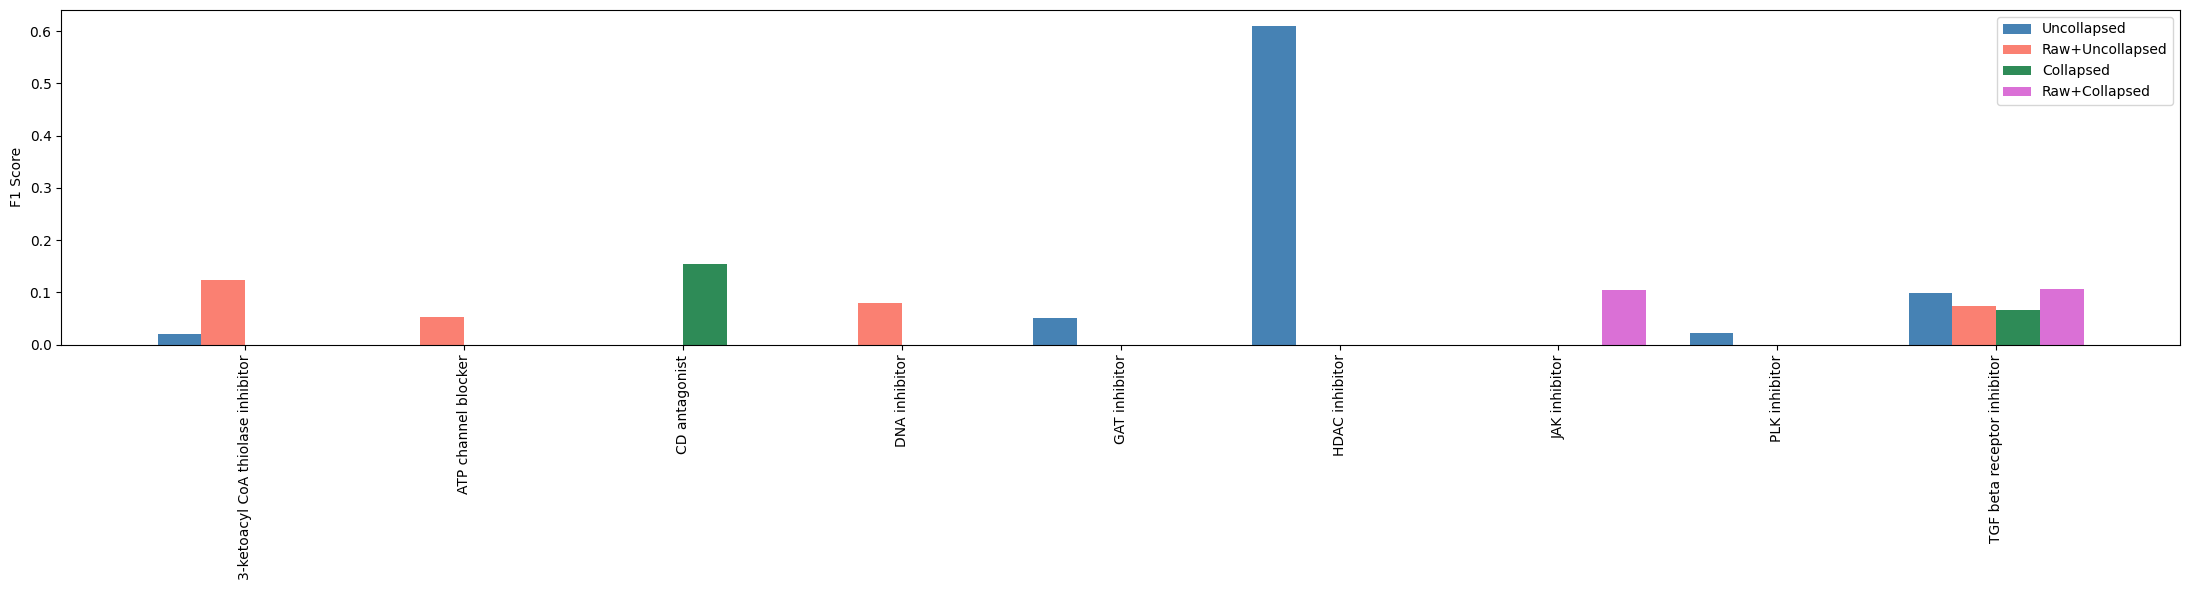

In [ ]:
groups = np.vstack([group_1, group_2, group_3, group_4])
mask = ~(np.all(groups == 0, axis=0))

f1_group1_f = group_1[mask]
f1_group2_f = group_2[mask]
f1_group3_f = group_3[mask]
f1_group4_f = group_4[mask]

class_names_f = [name for i, name in enumerate(class_names) if mask[i]]

groups_filtered = [f1_group1_f, f1_group2_f, f1_group3_f, f1_group4_f]

num_groups = len(groups_filtered)
num_classes = len(class_names_f)

x = np.arange(num_classes)
width = 0.8 / num_groups

plt.figure(figsize=(22, 6))

colors = ["steelblue", "salmon", "seagreen", "orchid"]
group_names =  ["Uncollapsed", "Raw+Uncollapsed", "Collapsed", "Raw+Collapsed"]

for i in range(num_groups):
    plt.bar(
        x + (i - num_groups/2) * width + width/2,
        groups_filtered[i],
        width,
        label=group_names[i],
        color=colors[i]
    )

plt.xticks(x, class_names_f, rotation=90)
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig('cross_comparison_f1.png')
plt.show()


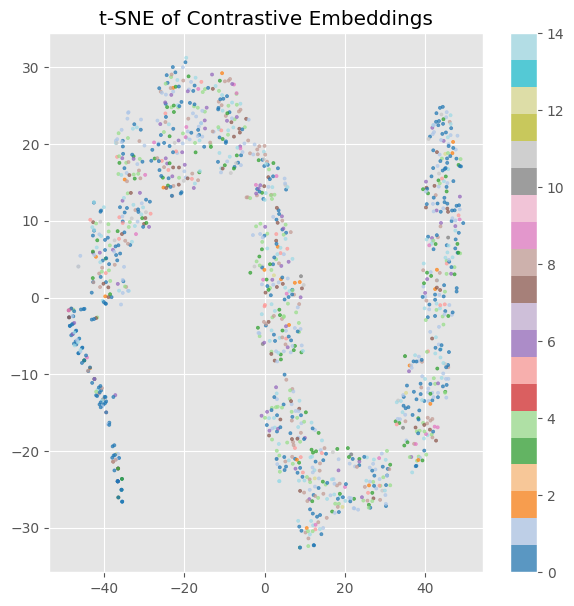

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
emb_tsne = tsne.fit_transform(train_embeddings)

plt.figure(figsize=(7,7))
plt.scatter(emb_tsne[:,0], emb_tsne[:,1], c=train_labels_mapped, s=5, alpha=0.7, cmap="tab20")
#add the legend using the broad_moa_dict
plt.colorbar()
plt.title("t-SNE of Contrastive Embeddings")
plt.show()